## Mapas por Região e Estado de Acidentes

A análise geográfica de acidentes no Brasil permite identificar padrões e concentrações de ocorrências em todo o território nacional. Por meio de mapas organizados por região e estado, gestores públicos conseguem visualizar onde os riscos são mais elevados e direcionar ações de forma mais eficiente.

Os dados utilizados nesses mapas são fornecidos principalmente pela **Polícia Rodoviária Federal (PRF)** e estão disponiveis em [gov.br/prf](https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos/dados-abertos-da-prf). Permiti identificar pontos críticos e orientar investimentos em sinalização, fiscalização e infraestrutura viária.

In [53]:
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import geobr as geobr
import folium

dados = pd.read_csv('acidentes2026_todas_causas_tipos.csv', encoding='latin-1', sep=';', decimal=',')
display(dados)

,id,pesid,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_principal,...,sexo,ilesos,feridos_leves,feridos_graves,mortos,latitude,longitude,regional,delegacia,uop
0,742884,1663693.0,2026-01-01,quinta-feira,00:05:00,SC,101.0,145.0,ITAPEMA,Sim,...,Masculino,0.0,1.0,0.0,0.0,-27.084768,-48.606356,SPRF-SC,DEL04-SC,UOP03-DEL04-SC
1,742885,1663697.0,2026-01-01,quinta-feira,00:20:00,PR,376.0,639.3,TIJUCAS DO SUL,Não,...,Masculino,1.0,0.0,0.0,0.0,-25.783081,-49.120916,SPRF-PR,DEL01-PR,UOP04-DEL01-PR
2,742885,1663697.0,2026-01-01,quinta-feira,00:20:00,PR,376.0,639.3,TIJUCAS DO SUL,Não,...,Masculino,1.0,0.0,0.0,0.0,-25.783081,-49.120916,SPRF-PR,DEL01-PR,UOP04-DEL01-PR
3,742885,1663697.0,2026-01-01,quinta-feira,00:20:00,PR,376.0,639.3,TIJUCAS DO SUL,Sim,...,Masculino,1.0,0.0,0.0,0.0,-25.783081,-49.120916,SPRF-PR,DEL01-PR,UOP04-DEL01-PR
4,742888,1663874.0,2026-01-01,quinta-feira,00:05:00,MG,262.0,108.0,SANTO ANTONIO DO GRAMA,Sim,...,Masculino,1.0,0.0,0.0,0.0,-20.270390,-42.570276,SPRF-MG,DEL03-MG,UOP03-DEL03-MG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101119,759804,1706908.0,2026-02-27,sexta-feira,20:18:00,MG,381.0,935.5,EXTREMA,Não,...,Masculino,1.0,0.0,0.0,0.0,-22.809040,-46.280025,SPRF-MG,DEL16-MG,UOP03-DEL16-MG
101120,759804,1706907.0,2026-02-27,sexta-feira,20:18:00,MG,381.0,935.5,EXTREMA,Não,...,Masculino,1.0,0.0,0.0,0.0,-22.809040,-46.280025,SPRF-MG,DEL16-MG,UOP03-DEL16-MG
101121,759835,1706993.0,2026-01-16,sexta-feira,20:30:00,RJ,101.0,43.0,CAMPOS DOS GOYTACAZES,Sim,...,Masculino,1.0,0.0,0.0,0.0,-21.597675,-41.316907,SPRF-RJ,DEL08-RJ,UOP01-DEL08-RJ
101122,759835,1706992.0,2026-01-16,sexta-feira,20:30:00,RJ,101.0,43.0,CAMPOS DOS GOYTACAZES,Sim,...,Masculino,1.0,0.0,0.0,0.0,-21.597675,-41.316907,SPRF-RJ,DEL08-RJ,UOP01-DEL08-RJ


In [61]:
contagens = (dados
    .groupby('uf')['mortos']
    .sum()
    .reset_index()
    .rename(columns={'mortos': 'Contagem_mortos'})
    .sort_values('Contagem_mortos', ascending=False)
)
print("TOP 10 estados com mais mortos:")
display(contagens.head(10))


TOP 10 estados com mais mortos:


,uf,Contagem_mortos
10,MG,573.0
17,PR,570.0
23,SC,308.0
8,GO,303.0
22,RS,266.0
12,MT,261.0
26,TO,237.0
15,PE,221.0
16,PI,216.0
20,RO,215.0


In [ ]:
# Baixa o GeoDataFrame com os estados do Brasil e DF
br_uf = geobr.read_state()  
br_uf_d = br_uf.merge(contagens, 
                     left_on='abbrev_state',    
                     right_on='uf', 
                     how='left')
br_uf_d = br_uf_d[["geometry", "Contagem_mortos"]]  
br_uf_d.head()

,geometry,Contagem_mortos
0,"MULTIPOLYGON (((-63.32721 -7.97672, -62.86662 ...",215.0
1,"MULTIPOLYGON (((-73.18253 -7.3355, -72.58477 -...",38.0
2,"MULTIPOLYGON (((-67.32609 2.02971, -67.31682 2...",60.0
3,"MULTIPOLYGON (((-60.20051 5.26434, -60.19273 5...",42.0
4,"MULTIPOLYGON (((-54.95431 2.58369, -54.93542 2...",148.0


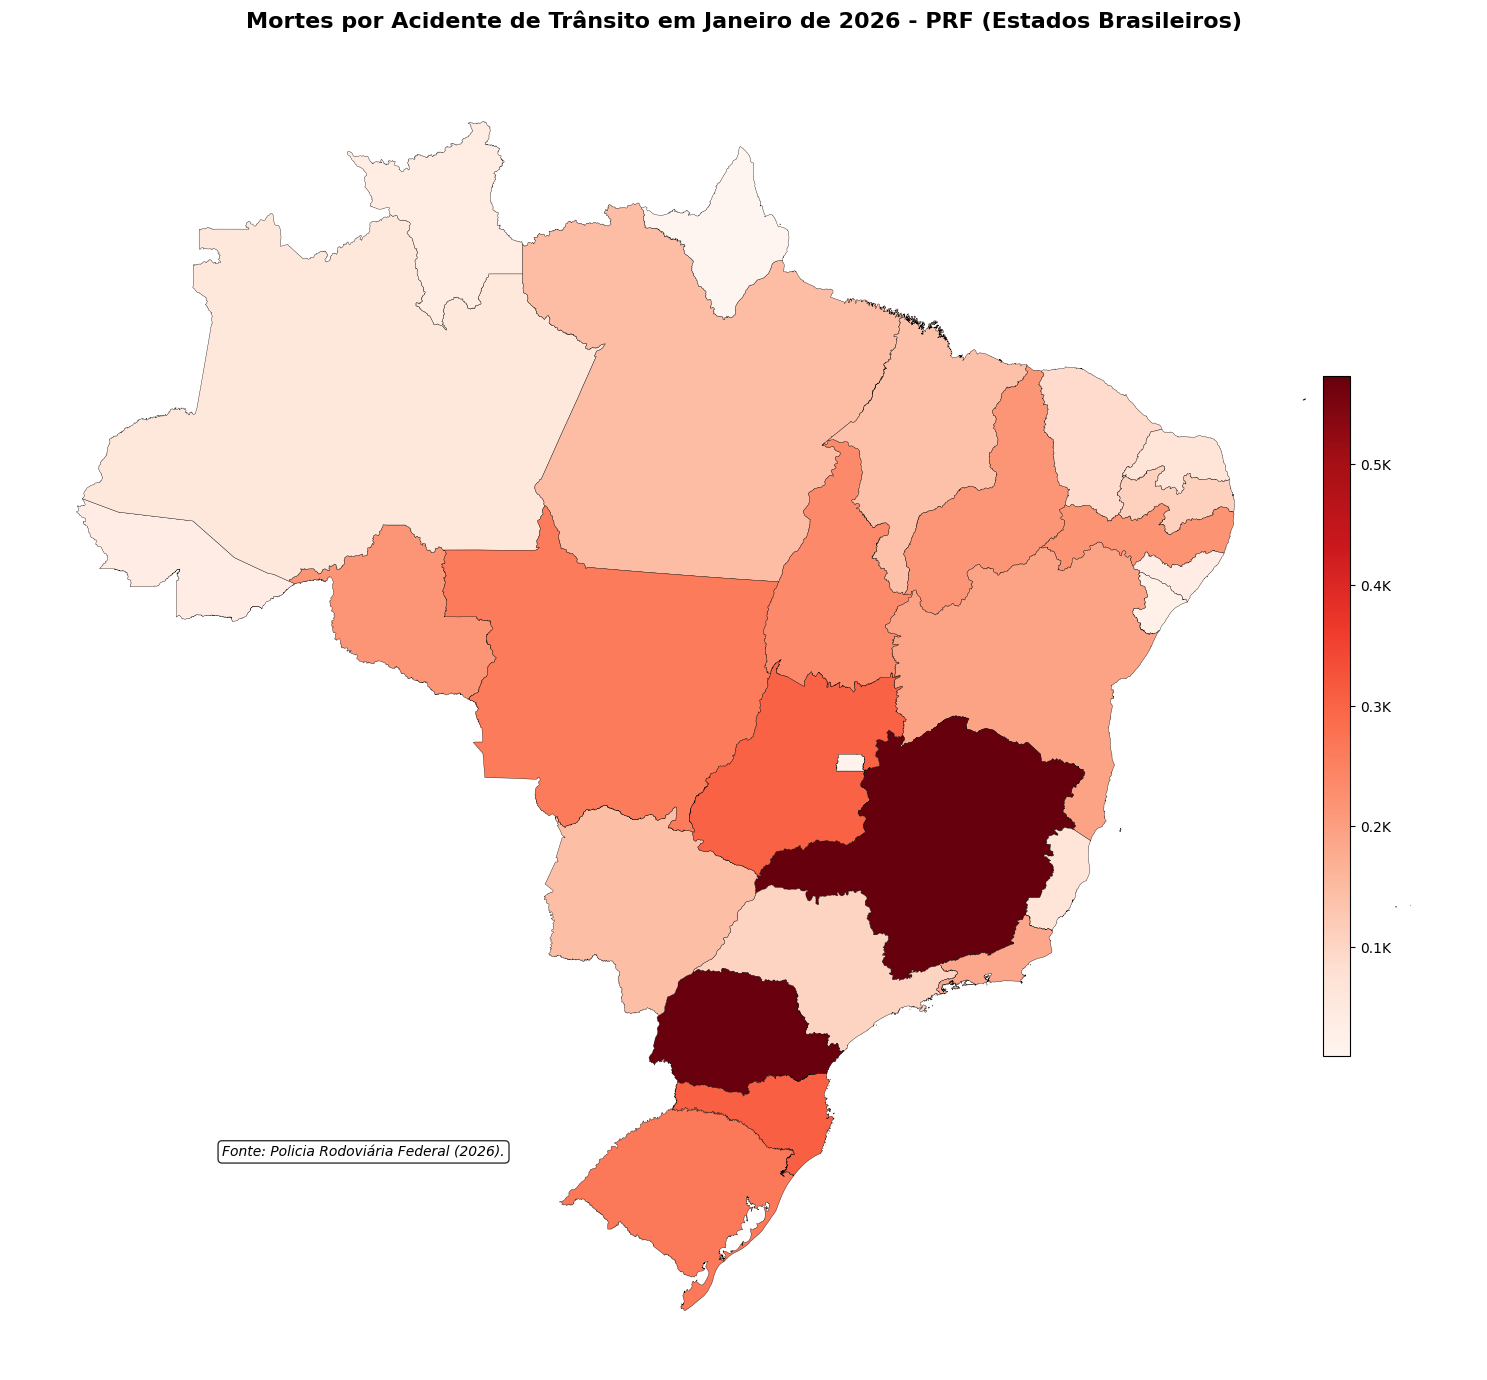

In [92]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Cria figura 16x16 polegadas (quadrado Brasil) ← Tamanho ideal para mapas
f, ax = plt.subplots()
f.set_size_inches(16, 16)  # Define dimensões da figura

# Plota mapa coroplético com acidentes PRF ← Coluna com contagens de mortes
br_uf_d.plot(
    ax=ax,                           # Eixo onde desenha
    column="Contagem_mortos",        # Coluna numérica para colorir estados
    cmap="Reds",                     # Paleta vermelho (acidentes graves)
    edgecolor="black",               # Bordas pretas entre estados
    linewidth=0.25,                  # Espessura fina das bordas
    legend=False,                    # Desabilita legenda padrão (usaremos colorbar custom)
    missing_kwds={'color': 'lightgrey', 'label': 'Sem dados'}  # Estados sem acidentes = cinza
)

# Título principal do gráfico ← Especifica Janeiro 2026 + PRF
ax.set_title(
    "Mortes por Acidente de Trânsito em Janeiro de 2026 - PRF (Estados Brasileiros)", 
    fontsize=16,                     # Tamanho fonte
    fontweight='bold',               # Negrito
    pad=25                          # Espaço acima do mapa
)

# Remove eixos (X/Y) para foco no mapa ← Estilo limpo "cartográfico"
ax.set_axis_off()

# Colorbar customizada (legenda de cores) ← Formata mortes em milhares
cbar = plt.colorbar(
    ax.collections[0],               # Primeiro polígono colorido (mappable)
    ax=ax,                           # Alinha com mapa
    shrink=0.5,                      # Reduz altura (50%)
    pad=-0.1,                        # Cola na borda direita
    aspect=25                        # Proporção retangular
)

# Formata colorbar: 573 → 0.6K ← Milhares mais legível
cbar.formatter = ticker.FuncFormatter(
    lambda x, pos: f'{x/1000:.1f}K'  # x/1000 = milhares, :.1f = 1 casa decimal
)
cbar.update_ticks()              # Aplica formatação

# Fonte dos dados (rodapé) ← Canto inferior esquerdo
f.text(
    0.15,                           # Posição X (15% da largura)
    0.20,                           # Posição Y (20% da altura)
    "Fonte: Policia Rodoviária Federal (2026).",  # Texto fonte oficial
    fontsize=10,                    # Fonte menor
    style='italic',                 # Itálico profissional
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)  # Caixa branca
)

# MELHORIAS adicionais ← Layout final
plt.tight_layout(pad=2)          # Espaçamento automático
plt.subplots_adjust(bottom=0.05, top=0.9)  # Margens otimizadas

# Salva alta resolução para relatórios ← 300 DPI profissional
#f.savefig('acidentes_prf_janeiro_2026.png', dpi=300, bbox_inches='tight', 
#          facecolor='white', edgecolor='none')
plt.show()

O mapa evidencia a distribuição espacial das mortes por acidentes de trânsito no Brasil, apresentando padrão semelhante ao observado para os feridos graves. Há forte concentração de óbitos nas regiões Sudeste e Sul, com destaque para Minas Gerais e Paraná, que apresentam os maiores valores absolutos.

As regiões Norte e parte do Nordeste registram menores números de mortes, enquanto o Centro-Oeste apresenta níveis intermediários. Esse padrão reforça a influência de fatores como volume de tráfego, densidade populacional e extensão da malha rodoviária, mais intensos nas regiões mais desenvolvidas.

De forma geral, a distribuição sugere que o número de óbitos está mais associado à exposição ao tráfego do que necessariamente ao risco individual. Assim, estados com maior circulação de veículos tendem a concentrar mais mortes.

Em síntese, observa-se uma clara concentração regional dos óbitos nas áreas com maior fluxo rodoviário, indicando a necessidade de análises complementares baseadas em taxas para avaliar de forma mais precisa o risco relativo entre os estados.


In [96]:
contagens = (dados
    .groupby('uf')['feridos_graves']
    .sum()
    .reset_index()
    .rename(columns={'feridos_graves': 'Contagem_feridos_graves'})
    .sort_values('Contagem_feridos_graves', ascending=False)
)
print("TOP 10 estados com mais feridos graves:")
display(contagens.head(10))


TOP 10 estados com mais feridos graves:


,uf,Contagem_feridos_graves
23,SC,1312.0
10,MG,1286.0
17,PR,1224.0
4,BA,943.0
8,GO,693.0
15,PE,604.0
14,PB,561.0
16,PI,535.0
12,MT,499.0
22,RS,445.0


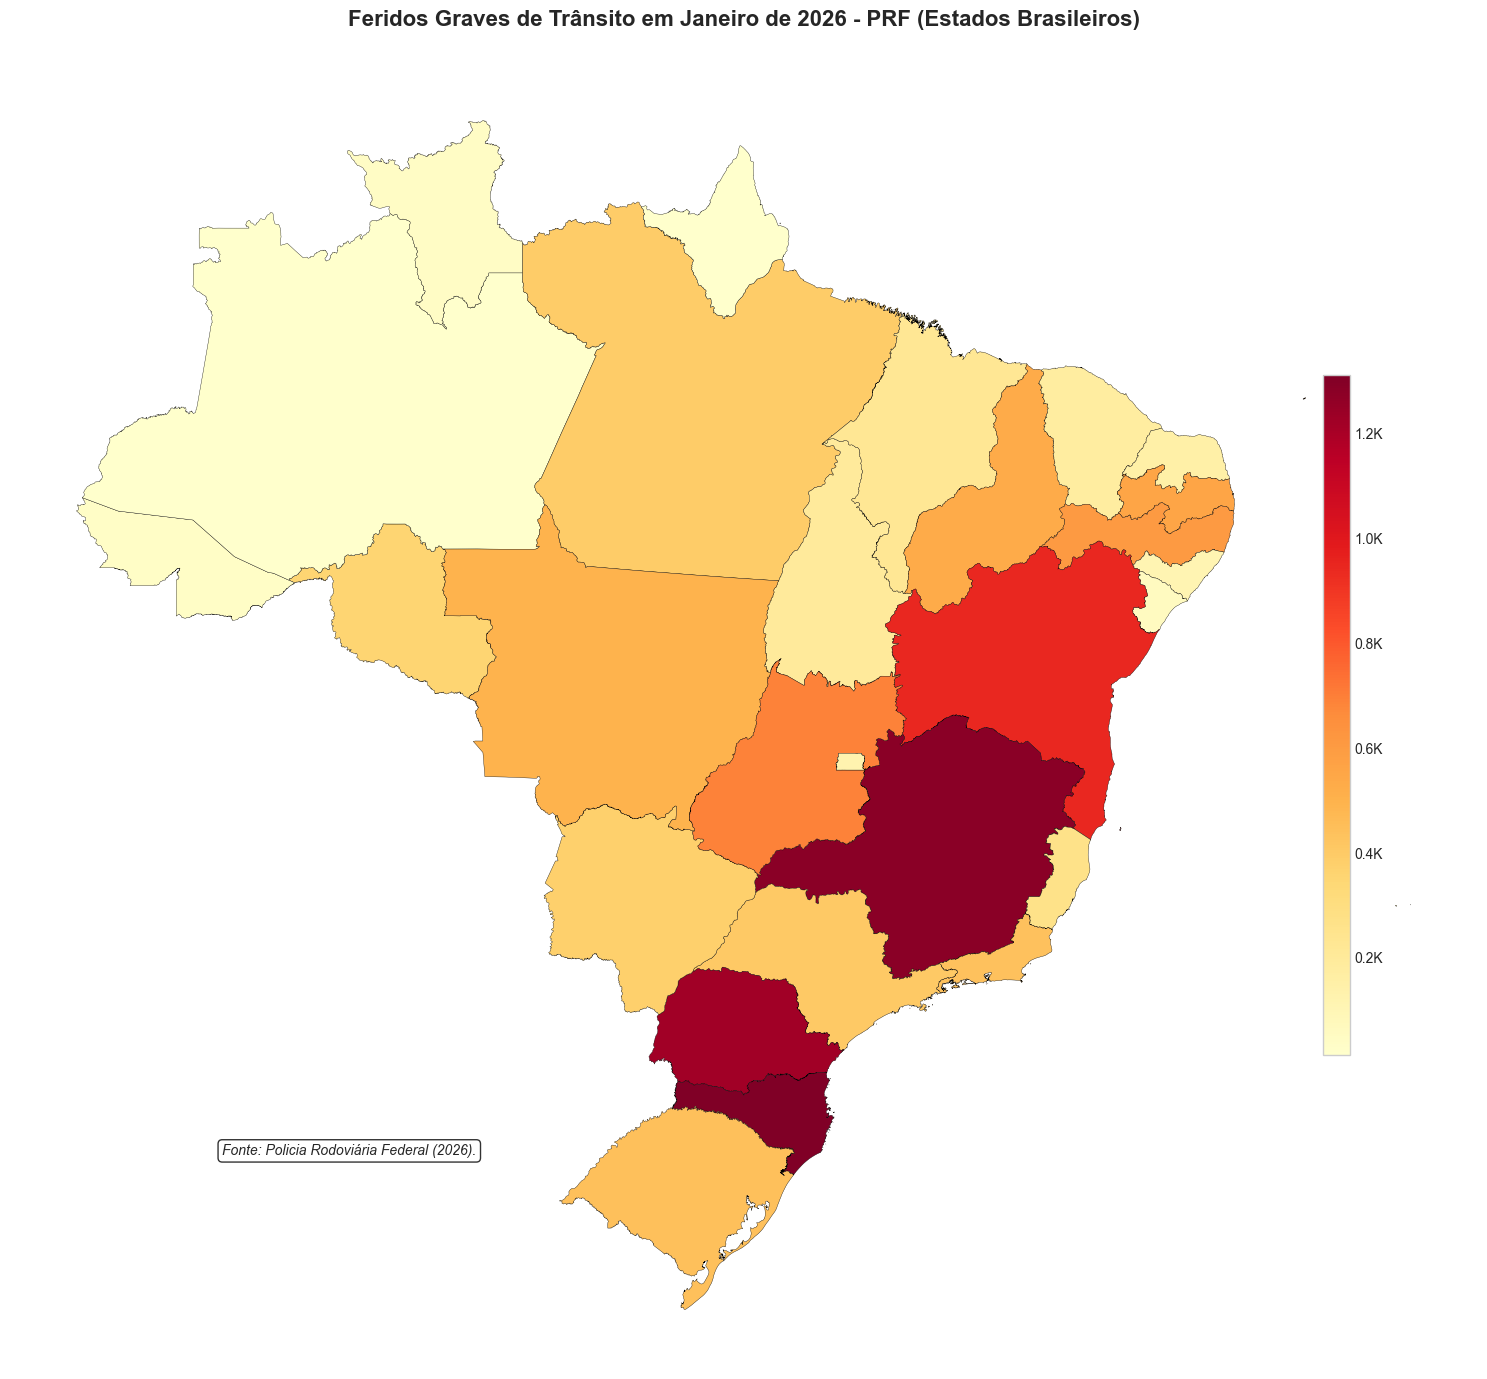

In [109]:
br_uf_d = br_uf.merge(contagens, 
                     left_on='abbrev_state',    
                     right_on='uf', 
                     how='left')
br_uf_d = br_uf_d[["geometry", "Contagem_feridos_graves"]]
f, ax = plt.subplots()
f.set_size_inches(16, 16) 
br_uf_d.plot(
    ax=ax,                           
    column="Contagem_feridos_graves",        
    cmap="YlOrRd",                     
    edgecolor="black",              
    linewidth=0.25,                 
    legend=False,                   
    missing_kwds={'color': 'lightgrey', 'label': 'Sem dados'} 
)
ax.set_title(
    "Feridos Graves de Trânsito em Janeiro de 2026 - PRF (Estados Brasileiros)", 
    fontsize=16,                     
    fontweight='bold',              
    pad=25                          
)

ax.set_axis_off()
cbar = plt.colorbar(
    ax.collections[0],               
    ax=ax,                           
    shrink=0.5,                      
    pad=-0.1,                       
    aspect=25                        
)

cbar.formatter = ticker.FuncFormatter(
    lambda x, pos: f'{x/1000:.1f}K'  
)
cbar.update_ticks()              
f.text(
    0.15,                           
    0.20,                        
    "Fonte: Policia Rodoviária Federal (2026).",  
    fontsize=10,                    
    style='italic',                 
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8) 
)
plt.tight_layout(pad=2)         
plt.subplots_adjust(bottom=0.05, top=0.9)  
#f.savefig('acidentes_prf_janeiro_2026.png', dpi=300, bbox_inches='tight', 
#          facecolor='white', edgecolor='none')
plt.show()

O mapa apresenta a distribuição espacial do número de feridos graves em acidentes de trânsito no Brasil, evidenciando forte concentração nas regiões Sudeste e Sul. Destaca-se especialmente o estado de Minas Gerais, com o maior volume absoluto, seguido por estados como São Paulo, Paraná e Rio Grande do Sul.

Nas regiões Norte e parte do Nordeste, observa-se menor intensidade, indicando menor número absoluto de ocorrências. Já o Centro-Oeste apresenta valores intermediários, sem grandes destaques em relação ao restante do país.

Esse padrão sugere que o número de feridos graves está fortemente associado a fatores como maior densidade populacional, volume de tráfego e extensão da malha rodoviária, mais intensos nas regiões mais desenvolvidas do país. Portanto, não necessariamente indica maior risco relativo, mas sim maior exposição ao tráfego.

Em síntese, há uma clara concentração espacial dos casos nas regiões com maior fluxo de veículos, reforçando a necessidade de análises complementares que considerem taxas (por população ou frota) para uma avaliação mais precisa do risco.


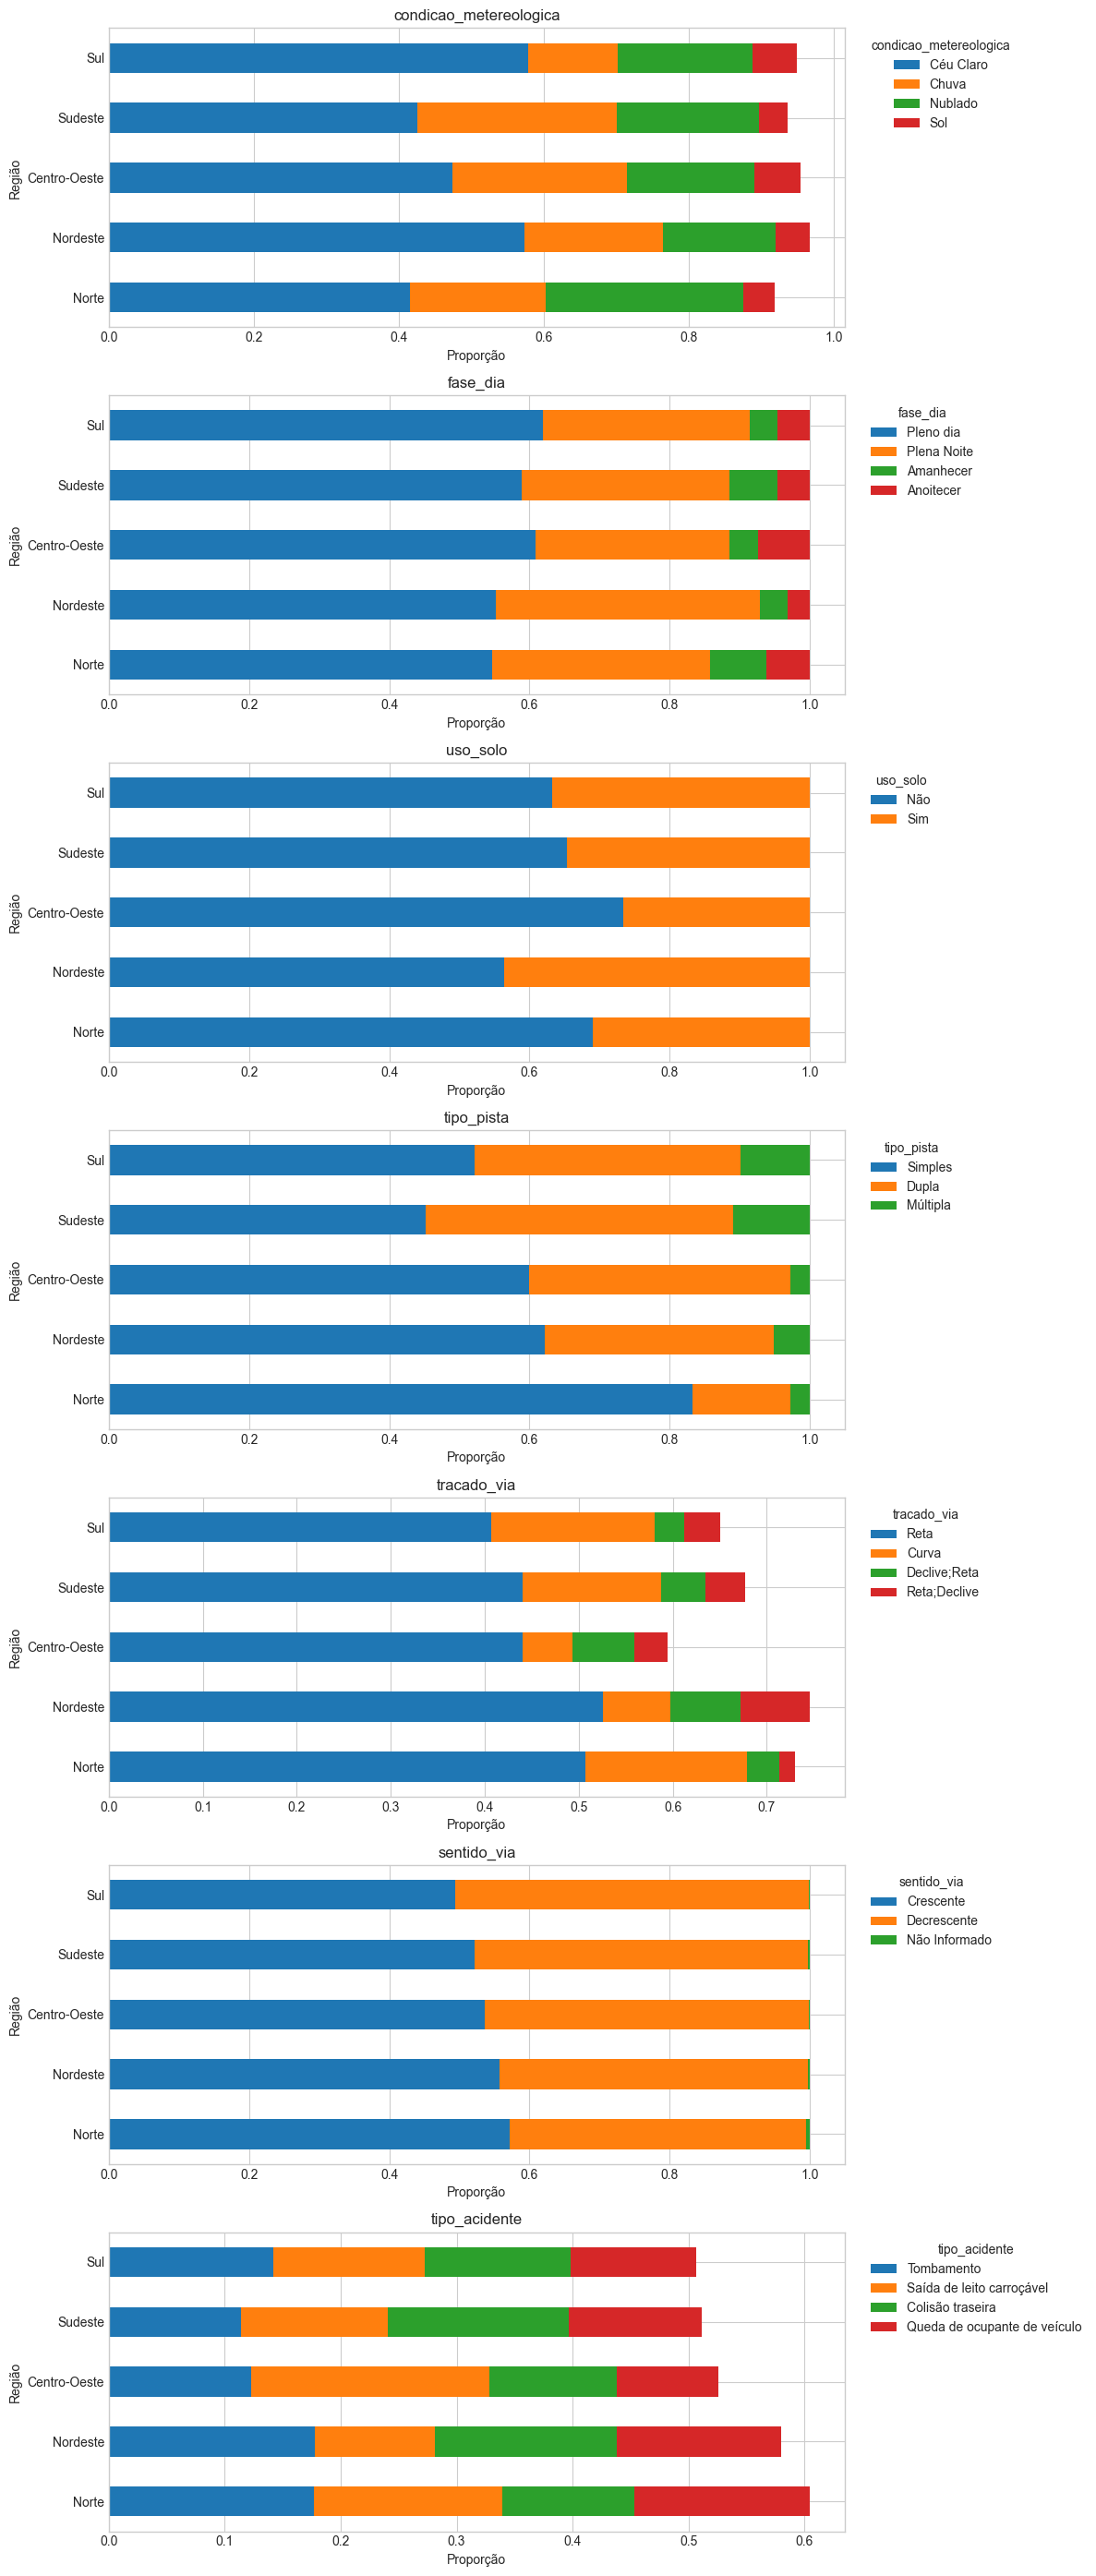

In [130]:
import pandas as pd
import matplotlib.pyplot as plt

map_regiao = {
    "AC":"Norte","AP":"Norte","AM":"Norte","PA":"Norte","RO":"Norte","RR":"Norte","TO":"Norte",
    "AL":"Nordeste","BA":"Nordeste","CE":"Nordeste","MA":"Nordeste","PB":"Nordeste","PE":"Nordeste","PI":"Nordeste","RN":"Nordeste","SE":"Nordeste",
    "DF":"Centro-Oeste","GO":"Centro-Oeste","MT":"Centro-Oeste","MS":"Centro-Oeste",
    "ES":"Sudeste","MG":"Sudeste","RJ":"Sudeste","SP":"Sudeste",
    "PR":"Sul","RS":"Sul","SC":"Sul"
}

dados["regiao"] = dados["uf"].map(map_regiao)

col_names = [
    "condicao_metereologica", "fase_dia", "uso_solo",
    "tipo_pista", "tracado_via", "sentido_via", "tipo_acidente"
]

ordem = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]

fig, axes = plt.subplots(len(col_names), 1, figsize=(12, 4 * len(col_names)))

if len(col_names) == 1:
    axes = [axes]

for i, col in enumerate(col_names):
    tab = pd.crosstab(
        dados["regiao"],
        dados[col],
        normalize="index"
    )

    top_cat = dados[col].value_counts().nlargest(4).index
    tab = tab[top_cat]
    tab = tab.reindex(ordem)

    tab.plot(
        kind="barh",
        stacked=True,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("Proporção")
    axes[i].set_ylabel("Região")
    axes[i].legend(
        title=col,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

plt.tight_layout()
plt.show()

A figura apresenta a distribuição proporcional das categorias das variáveis por macrorregião do Brasil, ou seja, mostra como os acidentes se distribuem internamente em cada região, independentemente do volume total.

De modo geral, as condições meteorológicas e a fase do dia apresentam padrões semelhantes entre as regiões, com predominância de céu claro e ocorrências durante o período diurno, indicando que esses fatores não diferenciam significativamente o perfil regional dos acidentes.

O uso do solo evidencia que a maior parte dos acidentes ocorre fora de áreas urbanas, reforçando o caráter rodoviário dos dados analisados.

As principais diferenças regionais aparecem na variável tipo de pista. Norte e Centro-Oeste concentram maior proporção de acidentes em pistas simples, enquanto Sudeste e Sul apresentam maior participação de pistas duplas, refletindo diferenças na infraestrutura viária.

Quanto ao tipo de acidente, observa-se que Norte e Nordeste apresentam maior participação de eventos associados à perda de controle ou maior vulnerabilidade, enquanto Sudeste e Sul concentram mais colisões traseiras, padrão típico de regiões com maior fluxo de veículos.

Em síntese, os resultados indicam que o perfil dos acidentes varia entre as regiões e está mais associado às condições estruturais das rodovias e ao padrão de tráfego do que a fatores ambientais.
